1. Cargando y preprocesando dataset de posturas...
-> Imágenes de entrenamiento: 1095
-> Imágenes de validación (examen): 274

2. Construyendo la arquitectura de la RNAC...


c:\Users\alber\OneDrive\Escritorio\FIME\prueba brazo robot ia\entorno_ia\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



3. Iniciando entrenamiento (Epochs)...
Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.5945 - loss: 0.6615 - val_accuracy: 0.7080 - val_loss: 0.5669
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.7169 - loss: 0.5285 - val_accuracy: 0.6642 - val_loss: 0.5585
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.7772 - loss: 0.4416 - val_accuracy: 0.8139 - val_loss: 0.3751
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.8283 - loss: 0.3621 - val_accuracy: 0.8248 - val_loss: 0.2961
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.8493 - loss: 0.3195 - val_accuracy: 0.8832 - val_loss: 0.2740
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.8502 - loss: 0.3071 - val_accuracy: 0.8431 - val_loss: 0.2948
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - accuracy: 0.8941 - loss: 0.2238 - val_accuracy: 0.9343 - val_loss: 0.1884
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accurac


[ÉXITO] Modelo guardado como 'cerebro_rover_colapso.h5'


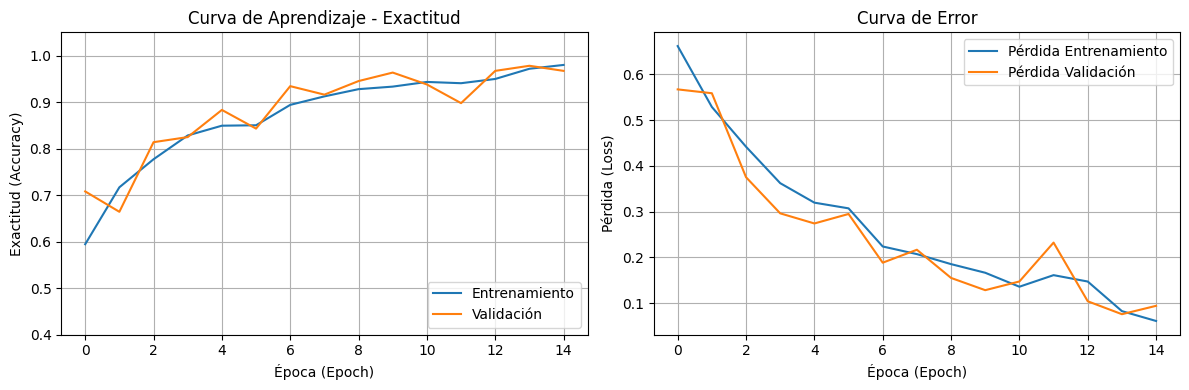

9/9 - 1s - 63ms/step - accuracy: 0.9672 - loss: 0.0941

Calificación final de la IA en el examen: 96.72% de precisión.


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("1. Cargando y preprocesando dataset de posturas...")
ruta_dataset = 'Dataset_Posturas'
categorias = ['0_Normal', '1_Colapso'] 

imagenes = []
etiquetas = []

# Leer imágenes y convertirlas a matrices matemáticas
for categoria in categorias:
    path = os.path.join(ruta_dataset, categoria)
    etiqueta_num = categorias.index(categoria)
    
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Escala de grises
        if img_array is not None:
            img_resized = cv2.resize(img_array, (64, 64)) # Redimensionar a 64x64
            imagenes.append(img_resized)
            etiquetas.append(etiqueta_num)

X = np.array(imagenes).reshape(-1, 64, 64, 1) # Formato para la convolución (1 canal)
y = np.array(etiquetas)

# Dividir 80% entrenamiento, 20% validación y normalizar (0 a 1)
train_images, test_images, train_labels, test_labels = train_test_split(X, y, test_size=0.2, random_state=42)
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f"-> Imágenes de entrenamiento: {len(train_images)}")
print(f"-> Imágenes de validación (examen): {len(test_images)}")

# ---------------------------------------------------------
# 2. ESTRUCTURA DE LA RED NEURONAL ARTIFICIAL CONVOLUCIONAL
# ---------------------------------------------------------
print("\n2. Construyendo la arquitectura de la RNAC...")
model = models.Sequential()
# Capas de extracción de características (Igual al GitHub del Dr.)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Capas de clasificación (Red Densa)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2, activation='softmax')) # 2 Salidas: Normal o Colapso

# Compilación
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# ---------------------------------------------------------
# 3. ENTRENAMIENTO (Aquí la compu se pondrá a trabajar duro)
# ---------------------------------------------------------
print("\n3. Iniciando entrenamiento (Epochs)...")
history = model.fit(train_images, train_labels, epochs=15, 
                    validation_data=(test_images, test_labels))

# Guardar el cerebro artificial
model.save('cerebro_rover_colapso.h5')
print("\n[ÉXITO] Modelo guardado como 'cerebro_rover_colapso.h5'")

# ---------------------------------------------------------
# 4. RESULTADOS Y GRÁFICAS
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

# Gráfica de Exactitud
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época (Epoch)')
plt.ylabel('Exactitud (Accuracy)')
plt.title('Curva de Aprendizaje - Exactitud')
plt.ylim([0.4, 1.05])
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica de Pérdida (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época (Epoch)')
plt.ylabel('Pérdida (Loss)')
plt.title('Curva de Error')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Examen Final
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nCalificación final de la IA en el examen: {test_acc*100:.2f}% de precisión.")

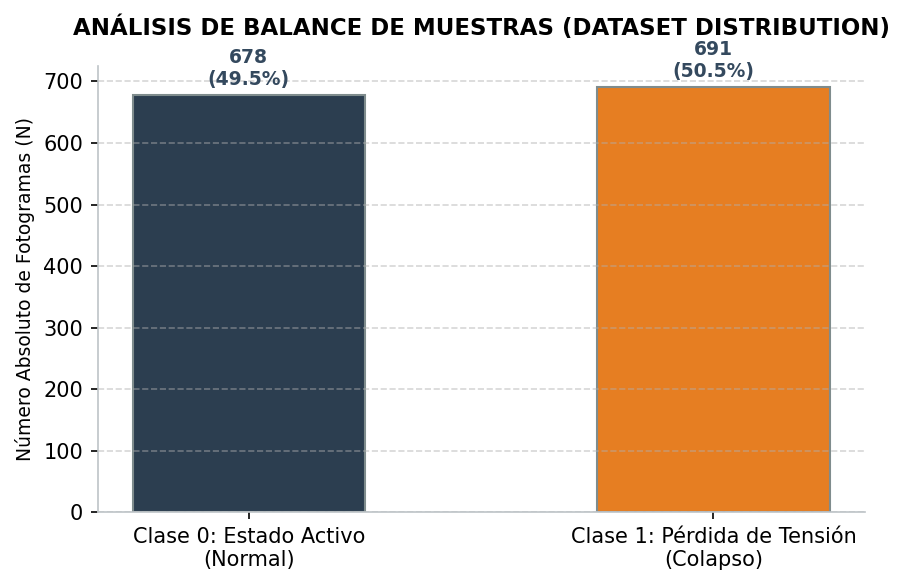

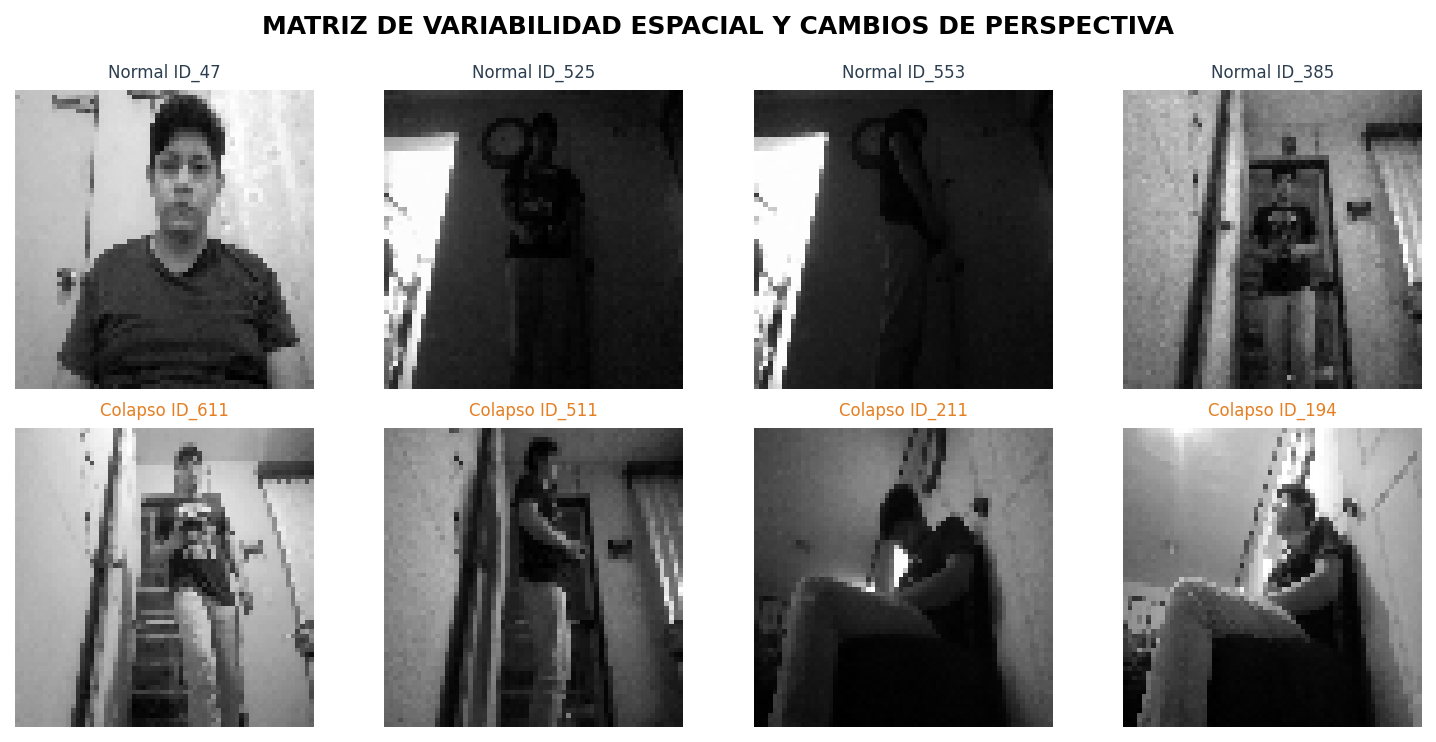

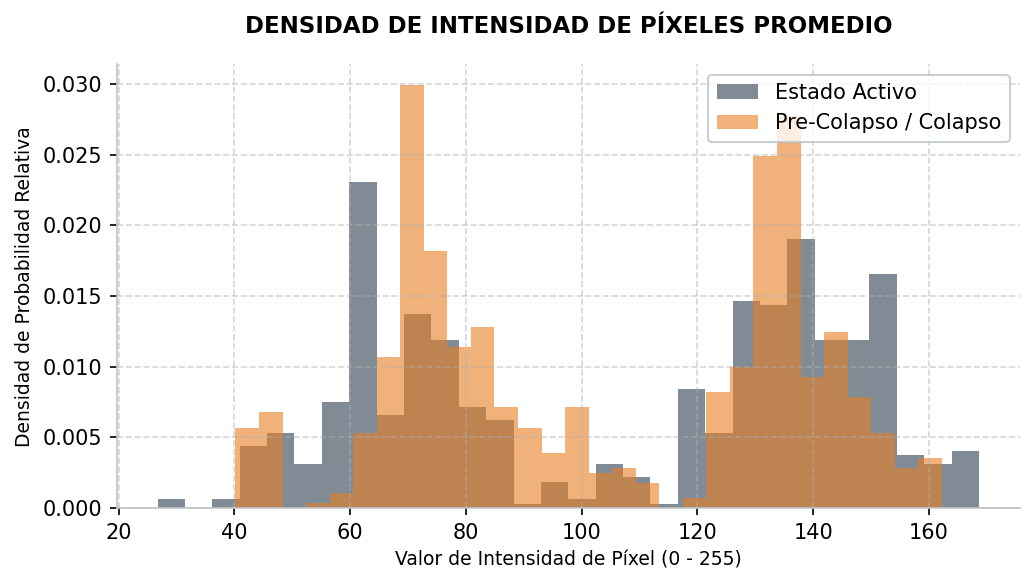

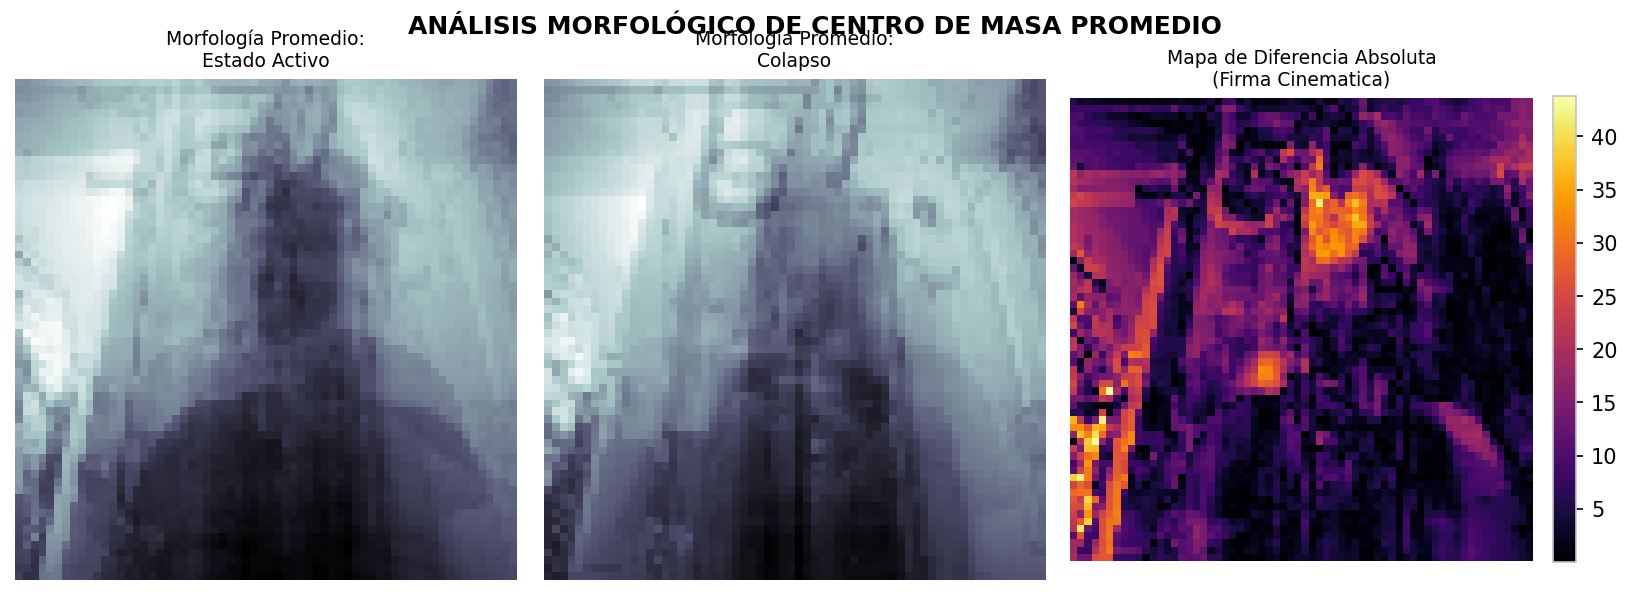

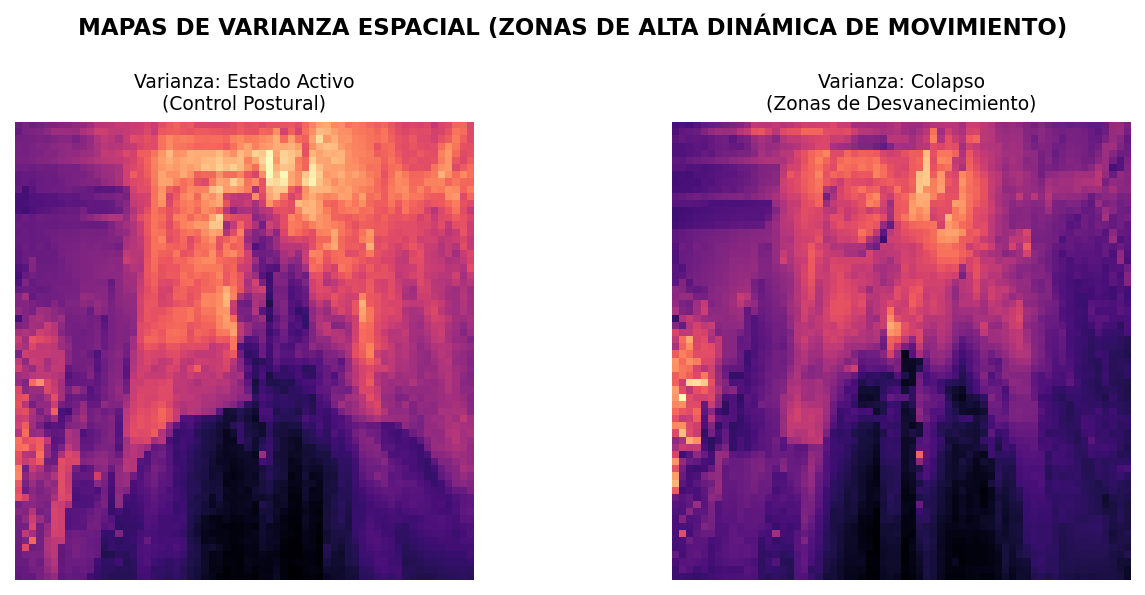

C:\Users\alber\AppData\Local\Temp\ipykernel_28104\2116641873.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax6.boxplot([densidad_normal, densidad_colapso], patch_artist=True, labels=['Estado Activo', 'Colapso'])


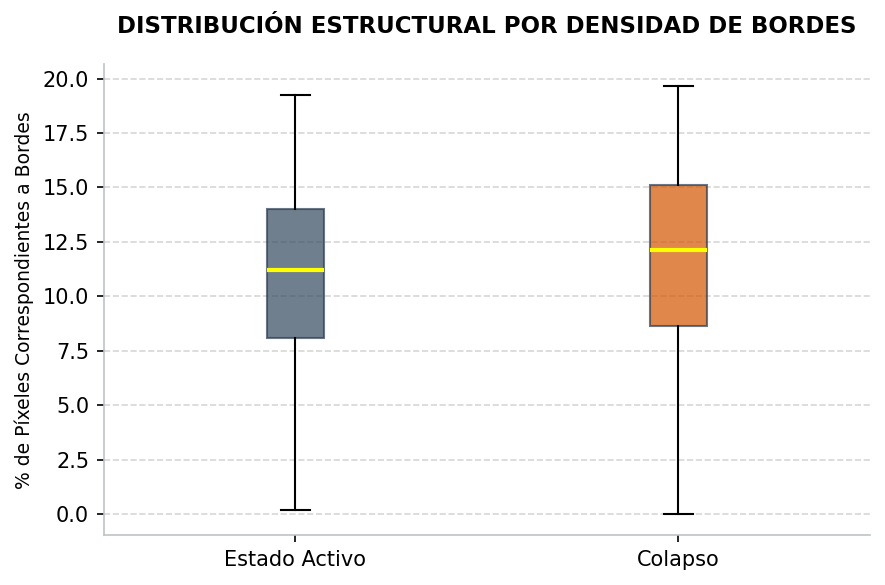

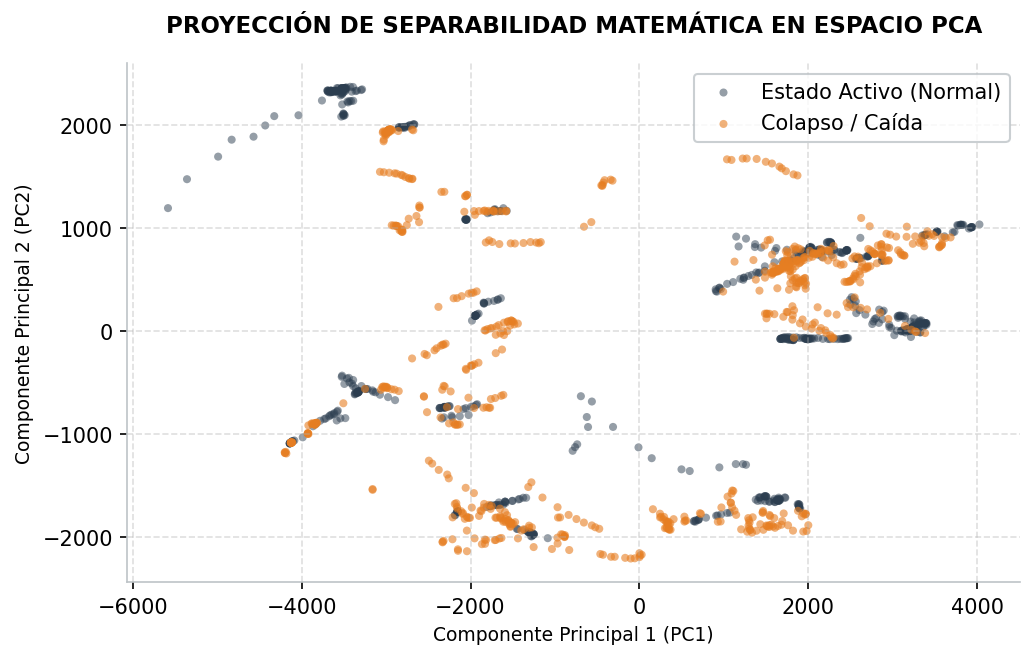

In [3]:
# CELDA: Análisis Exploratorio Avanzado y Visualización de Grado Científico (MIT Style)
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Configuración de estilo global tipo Laboratorio de Investigación
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.edgecolor'] = '#BDC3C7'
plt.rcParams['axes.linewidth'] = 0.8

# 1. Carga de datos para análisis estadístico
ruta_normal = 'Dataset_Posturas/0_Normal'
ruta_colapso = 'Dataset_Posturas/1_Colapso'

archivos_normal = [os.path.join(ruta_normal, f) for f in os.listdir(ruta_normal) if f.endswith('.png')]
archivos_colapso = [os.path.join(ruta_colapso, f) for f in os.listdir(ruta_colapso) if f.endswith('.png')]

imgs_normal = [cv2.imread(f, cv2.IMREAD_GRAYSCALE) for f in archivos_normal]
imgs_colapso = [cv2.imread(f, cv2.IMREAD_GRAYSCALE) for f in archivos_colapso]

arr_normal = np.array(imgs_normal)
arr_colapso = np.array(imgs_colapso)

# ==============================================================================
# GRÁFICA 1: Distribución y Balance de Clases (Muted Palette)
# ==============================================================================
plt.figure(figsize=(6, 4))
ax1 = plt.gca()
clases = ['Clase 0: Estado Activo\n(Normal)', 'Clase 1: Pérdida de Tensión\n(Colapso)']
cantidades = [len(arr_normal), len(arr_colapso)]
colores = ['#2C3E50', '#E67E22'] # Azul Pizarra y Terracota Desaturado

bars = ax1.bar(clases, cantidades, color=colores, width=0.5, edgecolor='#7F8C8D', linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('ANÁLISIS DE BALANCE DE MUESTRAS (DATASET DISTRIBUTION)', fontsize=11, fontweight='bold', pad=15)
plt.ylabel('Número Absoluto de Fotogramas (N)', fontsize=9)

for bar in bars:
    yval = bar.get_height()
    percentage = (yval / sum(cantidades)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#34495E')
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 2: Mosaico Estructurado de Variedad Estocástica
# ==============================================================================
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle('MATRIZ DE VARIABILIDAD ESPACIAL Y CAMBIOS DE PERSPECTIVA', fontsize=12, fontweight='bold', y=0.98)

for i in range(4):
    # Fila Normal
    idx_n = random.randint(0, len(arr_normal)-1)
    axes[0, i].imshow(arr_normal[idx_n], cmap='gray')
    axes[0, i].set_title(f"Normal ID_{idx_n}", fontsize=8, color='#2C3E50')
    axes[0, i].axis('off')
    
    # Fila Colapso
    idx_c = random.randint(0, len(arr_colapso)-1)
    axes[1, i].imshow(arr_colapso[idx_c], cmap='gray')
    axes[1, i].set_title(f"Colapso ID_{idx_c}", fontsize=8, color='#E67E22')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 3: Perfil de Densidad de Intensidad Lumínica (Validación de Sesgo)
# ==============================================================================
plt.figure(figsize=(7, 4))
ax3 = plt.gca()
mean_intensities_normal = [np.mean(img) for img in arr_normal]
mean_intensities_colapso = [np.mean(img) for img in arr_colapso]

ax3.hist(mean_intensities_normal, bins=30, alpha=0.6, color='#2C3E50', label='Estado Activo', density=True)
ax3.hist(mean_intensities_colapso, bins=30, alpha=0.6, color='#E67E22', label='Pre-Colapso / Colapso', density=True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(linestyle='--', alpha=0.5)
plt.title('DENSIDAD DE INTENSIDAD DE PÍXELES PROMEDIO', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Valor de Intensidad de Píxel (0 - 255)', fontsize=9)
plt.ylabel('Densidad de Probabilidad Relativa', fontsize=9)
plt.legend(frameon=True, facecolor='white', edgecolor='#BDC3C7')
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 4: Firma Anatómica Promedio y Mapa de Diferencia Absoluta
# ==============================================================================
mean_normal_img = np.mean(arr_normal, axis=0)
mean_colapso_img = np.mean(arr_colapso, axis=0)
mapa_diferencia = np.abs(mean_normal_img - mean_colapso_img)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
fig.suptitle('ANÁLISIS MORFOLÓGICO DE CENTRO DE MASA PROMEDIO', fontsize=12, fontweight='bold', y=0.98)

im0 = axes[0].imshow(mean_normal_img, cmap='bone')
axes[0].set_title('Morfología Promedio:\nEstado Activo', fontsize=9)
axes[0].axis('off')

im1 = axes[1].imshow(mean_colapso_img, cmap='bone')
axes[1].set_title('Morfología Promedio:\nColapso', fontsize=9)
axes[1].axis('off')

im2 = axes[2].imshow(mapa_diferencia, cmap='inferno')
axes[2].set_title('Mapa de Diferencia Absoluta\n(Firma Cinematica)', fontsize=9)
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 5: Mapa de Incertidumbre y Varianza Estructural (Pixel-wise Variance)
# ==============================================================================
var_normal_img = np.var(arr_normal, axis=0)
var_colapso_img = np.var(arr_colapso, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('MAPAS DE VARIANZA ESPACIAL (ZONAS DE ALTA DINÁMICA DE MOVIMIENTO)', fontsize=11, fontweight='bold')

im_v1 = axes[0].imshow(var_normal_img, cmap='magma')
axes[0].set_title('Varianza: Estado Activo\n(Control Postural)', fontsize=9)
axes[0].axis('off')

im_v2 = axes[1].imshow(var_colapso_img, cmap='magma')
axes[1].set_title('Varianza: Colapso\n(Zonas de Desvanecimiento)', fontsize=9)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 6: Cuantificación de Gradientes por Densidad de Bordes (Canny)
# ==============================================================================
def calcular_densidad_bordes(dataset_imgs):
    densidades = []
    for img in dataset_imgs:
        bordes = cv2.Canny(img, 100, 200)
        porcentaje_bordes = (np.sum(bordes > 0) / (64 * 64)) * 100
        densidades.append(porcentaje_bordes)
    return densidades

densidad_normal = calcular_densidad_bordes(arr_normal)
densidad_colapso = calcular_densidad_bordes(arr_colapso)

plt.figure(figsize=(6, 4))
ax6 = plt.gca()
box = ax6.boxplot([densidad_normal, densidad_colapso], patch_artist=True, labels=['Estado Activo', 'Colapso'])
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.grid(axis='y', linestyle='--', alpha=0.5)

colores_box = ['#34495E', '#D35400']
for patch, color in zip(box['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('#2C3E50')

for median in box['medians']:
    median.set(color='#FFFF00', linewidth=2)

plt.title('DISTRIBUCIÓN ESTRUCTURAL POR DENSIDAD DE BORDES', fontsize=11, fontweight='bold', pad=15)
plt.ylabel('% de Píxeles Correspondientes a Bordes', fontsize=9)
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICA 7: Proyección Euclidiana de Alta Dimensionalidad mediante PCA 2D
# ==============================================================================
plt.figure(figsize=(7, 4.5))
ax7 = plt.gca()

# Aplanar imágenes (64x64 = 4096 dimensiones por foto)
X_flat_normal = arr_normal.reshape(len(arr_normal), -1)
X_flat_colapso = arr_colapso.reshape(len(arr_colapso), -1)
X_total_flat = np.vstack((X_flat_normal, X_flat_colapso))

# Aplicar Análisis de Componentes Principales
pca = PCA(n_components=2)
proyeccion = pca.fit_transform(X_total_flat)

# Separar proyecciones para graficar
proj_normal = proyeccion[:len(arr_normal)]
proj_colapso = proyeccion[len(arr_normal):]

ax7.scatter(proj_normal[:, 0], proj_normal[:, 1], color='#2C3E50', alpha=0.5, label='Estado Activo (Normal)', edgecolors='none', s=15)
ax7.scatter(proj_colapso[:, 0], proj_colapso[:, 1], color='#E67E22', alpha=0.6, label='Colapso / Caída', edgecolors='none', s=15)

ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.grid(linestyle='--', alpha=0.4)

plt.title('PROYECCIÓN DE SEPARABILIDAD MATEMÁTICA EN ESPACIO PCA', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=9)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=9)
plt.legend(frameon=True, facecolor='white', edgecolor='#BDC3C7')
plt.tight_layout()
plt.show()

In [ ]:
# SCRIPT DE INFERENCIA EN TIEMPO REAL Y PUENTE SERIAL
import cv2
import numpy as np
import serial
import time
from tensorflow.keras.models import load_model

# 1. Cargar el "Cerebro" que entrenaste
print("Cargando modelo neuronal...")
modelo = load_model('cerebro_rover_colapso.h5')
print("Modelo cargado exitosamente.")

# 2. Configurar Comunicación Serial (Comentado para pruebas sin Arduino)
arduino_conectado = False
puerto_com = 'COM3' # Cambiarás esto al COM de tu Arduino después
try:
    arduino = serial.Serial(puerto_com, 9600, timeout=1)
    time.sleep(2) # Dar tiempo a que el Arduino reinicie
    arduino_conectado = True
    print(f"Conexión exitosa con Arduino en {puerto_com}")
except:
    print("⚠️ Arduino no detectado. Ejecutando en Modo Simulación (Solo Pantalla).")

# 3. Variables de Control y Filtro de Estabilidad
cap = cv2.VideoCapture(0)
frames_colapso_consecutivos = 0
UMBRAL_ALARMA = 15 # Necesita 15 frames (~0.5 seg) seguidos de colapso para frenar
estado_emergencia = False

print("\nIniciando patrullaje visual. Presiona 'q' para salir.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    # Preprocesamiento para la IA
    # La IA fue entrenada con imágenes 64x64 en blanco y negro, divididas entre 255
    frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_resized = cv2.resize(frame_gris, (64, 64))
    frame_normalizado = frame_resized / 255.0
    frame_input = np.expand_dims(frame_normalizado, axis=(0, -1)) # Forma: (1, 64, 64, 1)

    # Inferencia (Predicción)
    prediccion = modelo.predict(frame_input, verbose=0)[0]
    probabilidad_colapso = prediccion[1] # Índice 1 es la Clase Colapso

    # Lógica de Diagnóstico
    if probabilidad_colapso > 0.85: # 85% de seguridad de que es colapso
        frames_colapso_consecutivos += 1
    else:
        frames_colapso_consecutivos = 0 # Se reinicia si la postura vuelve a ser normal
        estado_emergencia = False

    # Detonador de Alarma
    if frames_colapso_consecutivos >= UMBRAL_ALARMA:
        estado_emergencia = True

    # 4. Interfaz Visual e Instrucciones al Arduino
    if estado_emergencia:
        cv2.putText(frame, "!!! EMERGENCIA: COLAPSO DETECTADO !!!", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2) # Rojo
        cv2.rectangle(frame, (0, 0), (frame.shape[1], frame.shape[0]), (0, 0, 255), 10)
        
        if arduino_conectado:
            arduino.write(b'E') # Enviar 'E' de Emergencia (Frenar y Zumbador)
    else:
        cv2.putText(frame, "Estado: ACTIVO / NORMAL", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2) # Verde
        
        if arduino_conectado:
            arduino.write(b'A') # Enviar 'A' de Avanzar (Patrullando)

    # Mostrar medidor de probabilidad en pantalla
    cv2.putText(frame, f"Probabilidad Colapso: {probabilidad_colapso*100:.1f}%", (20, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    cv2.imshow('Cerebro Rover - Vista Inferencia', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
if arduino_conectado:
    arduino.close()

Cargando modelo neuronal...


Modelo cargado exitosamente.
Conexión exitosa con Arduino en COM3

Iniciando patrullaje visual. Presiona 'q' para salir.
